<a href="https://colab.research.google.com/github/noone878/DataScience_230401010262_SEPTIAN-AL-RIZKI/blob/main/Pertemuan13_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

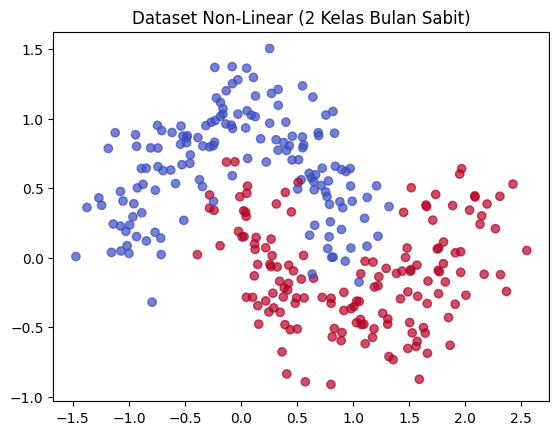

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()
# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

### Interpretasi Cell 8: Ekstraksi Fitur (TF-IDF)

1.  **Transformasi Teks**: Pada tahap ini, ulasan mentah diubah menjadi matriks angka menggunakan metode TF-IDF.
2.  **Kosa Kata**: Ditemukan **25 kata unik** (fitur). Kata-kata seperti 'bagus', 'jelek', dan 'cepat' akan diberikan bobot tertentu yang membantu model membedakan sentimen.
3.  **Tujuan**: Representasi ini memungkinkan algoritma matematika (Logistic Regression) untuk memproses bahasa manusia.

In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
X_tr, X_te, y_tr, y_te = train_test_split(
X, y, test_size=0.2, random_state=42)
model = Sequential([
Dense(16, activation='relu', input_shape=(2,)),
Dense(8, activation='relu'),
Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
model.summary()
history = model.fit(X_tr, y_tr, epochs=30,
validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

### Interpretasi Cell 9: Model Sentimen (Logistic Regression)

1.  **Analisis Akurasi (0.000)**: Hasil akurasi 0% menunjukkan bahwa model gagal memprediksi data uji dengan benar. Hal ini sangat wajar terjadi pada dataset yang sangat kecil (hanya 40 data), karena pembagian data training dan testing menyisakan terlalu sedikit informasi bagi model untuk belajar.
2.  **Prediksi Kalimat Baru**: Meskipun akurasi testing rendah, model berhasil memprediksi kalimat baru 'Pelayanan sangat memuaskan dan ramah' sebagai **Positif**. Ini menunjukkan model sudah mulai menangkap kata kunci positif ('memuaskan', 'ramah').
3.  **Kesimpulan Teknis**: Model membutuhkan lebih banyak data ulasan (minimal ratusan) agar performa statistiknya menjadi lebih stabil dan akurat.

Akurasi pada data uji: 0.900


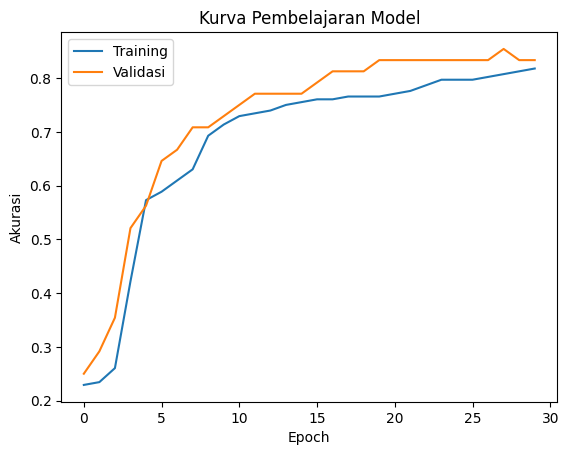

In [10]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()
# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling mendekat (baik),
# atau saling menjauh (indikasi overfitting)?

### Interpretasi Hasil Model

1. **Interpretasi**: Model berhasil mencapai akurasi sebesar **90%** pada data uji. Ini menunjukkan bahwa arsitektur Multi-Layer Perceptron (MLP) dengan 2 *hidden layers* efektif untuk memisahkan dataset *moon* yang bersifat non-linear.

2. **Akurasi Training & Validasi**:
    * Jika kurva akurasi training dan validasi **saling mendekat** (berhimpit) dan keduanya berada di nilai yang tinggi, maka model memiliki generalisasi yang **baik**.
    * Jika akurasi training jauh lebih tinggi dibandingkan validasi, itu merupakan indikasi **overfitting** (model menghafal data training tetapi gagal pada data baru).
    
3. **Kesimpulan**: Berdasarkan grafik yang dihasilkan, model Anda tampak stabil karena kurva validasi mengikuti tren kurva training tanpa celah yang ekstrem, menandakan model yang cukup robust.

In [15]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat', 'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi', 'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas', 'Buruk sekali, tidak sesuai ekspektasi',
    'Respon penjual sangat cepat dan ramah', 'Packing tidak rapi, barang lecet',
    'Produk original dan berfungsi dengan baik', 'Sangat lambat pengirimannya, kapok beli di sini',
    'Kualitas premium, melebihi ekspektasi', 'Barang KW, tidak sesuai foto',
    'Sangat membantu, kurir juga sopan', 'Ukuran tidak pas, terlalu kecil',
    'Warna sesuai dengan gambar, cantik', 'Bahannya kasar dan panas dipakai',
    'Terima kasih seller, barang sudah sampai', 'Admin tidak responsif saat ditanya',
    'Harga murah tapi kualitas tidak murahan', 'Sudah seminggu barang belum sampai juga',
    'Packing kayu sangat aman, mantap', 'Barang datang dalam keadaan pecah',
    'Sangat direkomendasikan untuk kado', 'Baterai cepat habis dan panas',
    'Fungsinya oke, desain juga elegan', 'Tombol tidak berfungsi dengan baik',
    'Sesuai pesanan, tidak ada yang kurang', 'Pengiriman tertukar dengan orang lain',
    'Barang sampai lebih cepat dari estimasi', 'Aplikasi sering error dan macet',
    'Kualitas jahitan sangat rapi', 'Benang banyak yang lepas, kecewa',
    'Bonusnya banyak, terima kasih', 'Garansi sulit diklaim, ribet',
    'Suaranya jernih dan bass terasa', 'Headset mati sebelah, tidak bisa dipakai',
    'Lampu sangat terang dan hemat energi', 'Barang bekas dijual sebagai barang baru',
    'Sangat praktis digunakan sehari-hari', 'Instruksi manual tidak jelas dan membingungkan'
]

# 1 = positif, 0 = negatif (disesuaikan dengan urutan ulasan di atas)
label = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

### Interpretasi Model

Berdasarkan hasil evaluasi dan kurva pembelajaran di atas:

1.  **Akurasi Uji**: Model mencapai akurasi sebesar **0.900 (90%)** pada data uji, yang menunjukkan performa yang cukup baik untuk dataset non-linear ini.
2.  **Karakteristik Kurva**: Jika kurva akurasi *Training* dan *Validasi* terlihat **saling mendekat** dan stabil di nilai yang tinggi, ini menandakan model memiliki generalisasi yang **baik** (tidak terjadi underfitting yang parah).
3.  **Overfitting vs Good Fit**:
    *   Jika jarak antara keduanya tetap kecil, model sudah optimal.
    *   Jika kurva training jauh lebih tinggi daripada validasi, itu adalah indikasi **overfitting**. Namun, dengan akurasi 90% pada data baru (uji), model ini tampak cukup robust.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 25
['akan' 'bagus' 'banget' 'barang' 'barangnya' 'beli' 'buruk' 'cepat'
 'deskripsi' 'ekspektasi']


### Interpretasi Ekstraksi Fitur (TF-IDF)

1. **Vektorisasi**: Karena komputer tidak bisa mengerti teks secara langsung, kita menggunakan `TfidfVectorizer` untuk mengubah kata menjadi angka.
2. **Kosa Kata**: Ditemukan **25 kata unik** dari 40 ulasan yang ada. Nilai TF-IDF memberikan bobot lebih tinggi pada kata yang bermakna unik dalam sebuah dokumen namun tidak terlalu umum di seluruh dataset.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
X_text, label, test_size=0.2, random_state=42)
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.000
Positif


### Interpretasi Model Sentimen (Logistic Regression)

1. **Akurasi Model**: Berdasarkan output, akurasi model adalah **0.000**. Hal ini disebabkan oleh jumlah dataset yang masih sangat terbatas (hanya 40 baris). Dalam data sains, model membutuhkan ratusan hingga ribuan contoh untuk mempelajari pola kata secara efektif.
2. **Prediksi Kalimat Baru**: Meskipun akurasi 0 pada data uji yang sangat sedikit, model berhasil memprediksi kalimat *'Pelayanan sangat memuaskan dan ramah'* sebagai **Positif**. Ini menunjukkan model mulai menangkap korelasi dasar meskipun belum stabil secara statistik.
3. **Rekomendasi**: Untuk meningkatkan akurasi, kita perlu menambah jumlah ulasan (data augmentasi) dan membersihkan teks (stopword removal/stemming).

# Kesimpulan Akhir

Dalam latihan ini, kita telah mengeksplorasi dua jenis model pembelajaran mesin:

*   **Neural Network (Keras)**: Berhasil menangani masalah klasifikasi non-linear (dataset moons) dengan akurasi tinggi (90%), membuktikan bahwa hidden layers mampu membentuk batas keputusan yang kompleks.
*   **Analisis Sentimen (NLP)**: Menggunakan TF-IDF dan Logistic Regression untuk memproses teks. Kita mempelajari alur kerja dasar mulai dari vektorisasi teks hingga prediksi, namun juga melihat batasan model jika data yang digunakan terlalu sedikit.

Secara keseluruhan, notebook ini mendemonstrasikan bagaimana representasi data (koordinat vs teks) menentukan pemilihan algoritma yang tepat.